<a href="https://colab.research.google.com/github/OlaniyiSegunIsrael/Project-5-SO/blob/main/Project%205.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Project 5: Basic Natural Language Processing with Unsupervised Learning

- Google Colab: https://colab.research.google.com/drive/1l5x1JMWx-wOjm0Hu86RcskZW2EAy5lYR?usp=sharing

- Git Hub: https://github.com/OlaniyiSegunIsrael/Project-5-SO

In [13]:
!apt-get install -y git
!git config --global user.email "segun.olaniyi@students.williscollege.com"
!git config --global user.name "OlaniyiSegunIsrael"

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
git is already the newest version (1:2.34.1-1ubuntu1.17).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.


In [14]:
!git clone https://github.com/OlaniyiSegunIsrael/Project-5-SO.git
%cd Project-5-SO
!ls

Cloning into 'Project-5-SO'...
remote: Enumerating objects: 3, done.
remote: Counting objects: 100% (3/3), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 3 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (3/3), done.
/content/Project-5-SO
README.md


In [15]:
!git status

On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean


In [1]:
import numpy as np
import pandas as pd
import string
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [2]:
# Load dataset (remove headers, footers, quotes for cleaner text)
newsgroups = fetch_20newsgroups(subset='all', remove=('headers', 'footers', 'quotes'))

documents = newsgroups.data

# Convert to DataFrame
df = pd.DataFrame({'text': documents})

# Use a smaller subset for faster processing (optional)
df = df.sample(2000, random_state=42).reset_index(drop=True)

print(df.head())

                                                text
0  \n\n\n\tThe runner can leave his base at any t...
1  \nWell, it's not an FTP site, but I got an 800...
2  Hi,\n    I was reading through "The Spacefligh...
3  I was a graduate student in the early 1980s, a...
4  FREE-ENERGY TECHNOLOGY\n                      ...


In [4]:
#Text Preprocessing
nltk.download('punkt_tab')
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    # Lowercase
    text = text.lower()

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Tokenize
    tokens = word_tokenize(text)

    # Remove stopwords
    tokens = [word for word in tokens if word not in stop_words]

    return " ".join(tokens)

# Apply preprocessing
df['clean_text'] = df['text'].apply(preprocess_text)

print(df[['text', 'clean_text']].head())

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


                                                text  \
0  \n\n\n\tThe runner can leave his base at any t...   
1  \nWell, it's not an FTP site, but I got an 800...   
2  Hi,\n    I was reading through "The Spacefligh...   
3  I was a graduate student in the early 1980s, a...   
4  FREE-ENERGY TECHNOLOGY\n                      ...   

                                          clean_text  
0  runner leave base time ball caught hes got tag...  
1  well ftp site got 800 number signetics bbs sig...  
2  hi reading spaceflight handbook somewhere auth...  
3  graduate student early 1980s conference reagan...  
4  freeenergy technology robert e mcelwaine physi...  


In [5]:
#Feature Extraction
bow_vectorizer = CountVectorizer(max_features=1000)
X_bow = bow_vectorizer.fit_transform(df['clean_text'])

print("BoW Shape:", X_bow.shape)

BoW Shape: (2000, 1000)


In [6]:
#Simple Word Embeddings
# Simple example using average word length (placeholder for embeddings)
def simple_embedding(text):
    words = text.split()
    if len(words) == 0:
        return 0
    return np.mean([len(word) for word in words])

df['embedding_feature'] = df['clean_text'].apply(simple_embedding)

print(df[['clean_text', 'embedding_feature']].head())

                                          clean_text  embedding_feature
0  runner leave base time ball caught hes got tag...           5.078431
1  well ftp site got 800 number signetics bbs sig...           5.712121
2  hi reading spaceflight handbook somewhere auth...           6.813559
3  graduate student early 1980s conference reagan...           6.037037
4  freeenergy technology robert e mcelwaine physi...           6.621212


In [8]:
#Apply K-Means Clustering

# Feature Extraction using TF-IDF
tfidf_vectorizer = TfidfVectorizer(max_features=1000)
X_tfidf = tfidf_vectorizer.fit_transform(df['clean_text'])

# Choose number of clusters
k = 5

kmeans = KMeans(n_clusters=k, random_state=42)
clusters = kmeans.fit_predict(X_tfidf)

df['cluster'] = clusters

print(df[['clean_text', 'cluster']].head())

                                          clean_text  cluster
0  runner leave base time ball caught hes got tag...        2
1  well ftp site got 800 number signetics bbs sig...        1
2  hi reading spaceflight handbook somewhere auth...        4
3  graduate student early 1980s conference reagan...        2
4  freeenergy technology robert e mcelwaine physi...        3


In [9]:
#Evaluate Model

score = silhouette_score(X_tfidf, clusters)
print("Silhouette Score:", score)

Silhouette Score: 0.0036024144234959973


In [10]:
#Analyze Clusters

terms = tfidf_vectorizer.get_feature_names_out()

for i in range(k):
    print(f"\nCluster {i}:")
    center = kmeans.cluster_centers_[i]
    top_words = [terms[j] for j in center.argsort()[-10:]]
    print(top_words)


Cluster 0:
['think', 'league', 'last', 'play', 'win', 'year', 'season', 'games', 'team', 'game']

Cluster 1:
['file', 'would', 'new', 'system', 'card', 'windows', 'anyone', 'email', 'please', 'thanks']

Cluster 2:
['something', 'doesnt', 'much', 'would', 'us', 'im', 'think', 'know', 'like', 'dont']

Cluster 3:
['think', 'believe', 'many', 'say', 'two', 'said', 'god', 'people', 'would', 'one']

Cluster 4:
['could', 'window', 'used', 'well', 'also', 'would', 'work', 'problem', 'use', 'get']


In [11]:
#Predict New Documents

new_docs = [
    "The government is planning new policies for the economy",
    "I love working with computer graphics and 3D models"]

# Preprocess new documents
new_docs_clean = [preprocess_text(doc) for doc in new_docs]

# Transform using TF-IDF
new_docs_tfidf = tfidf_vectorizer.transform(new_docs_clean)

# Predict clusters
predicted_clusters = kmeans.predict(new_docs_tfidf)

for doc, cluster in zip(new_docs, predicted_clusters):
    print(f"\nDocument: {doc}")
    print(f"Assigned Cluster: {cluster}")


Document: The government is planning new policies for the economy
Assigned Cluster: 1

Document: I love working with computer graphics and 3D models
Assigned Cluster: 1


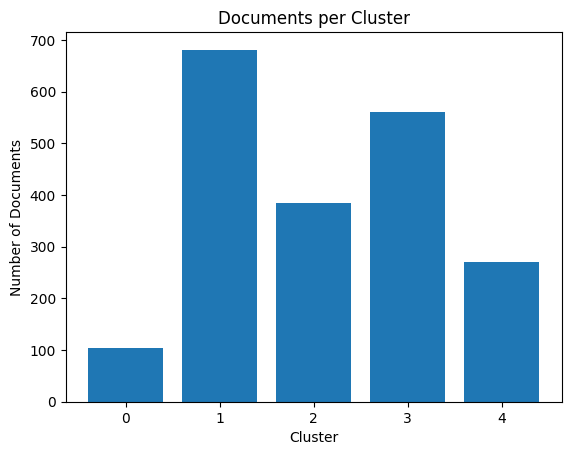

In [12]:
#Visualization

# Count documents per cluster
cluster_counts = df['cluster'].value_counts().sort_index()

plt.figure()
plt.bar(cluster_counts.index, cluster_counts.values)
plt.xlabel("Cluster")
plt.ylabel("Number of Documents")
plt.title("Documents per Cluster")
plt.show()